In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('../data/train.csv', encoding='latin-1')

print(f'первые 5 строк датасета:\n\n{df.head()}\n')
print(f'краткая инфо о датасете (столбцы, кол-во строк, кол-во null,\nиспользуемая память):\n\n')
print(df.info())
print(f'\nосновная статистика по столбцу Sales:\n\n {df['Sales'].describe().round(1)}')


первые 5 строк датасета:

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region   

---
Первичный обзор датасета показал, что некоторые колонки (в частности, **Order Date** и **Ship Date**), имеют тип данных *Object*, из-за чего в дальнейшем не получится строить динамику продаж по времени. Таким образом, дальше нужно преобразовать эти колонки в тип данных *Дата*.

In [136]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

#проверяем, что получилось

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

---
Также, исходя из первоначального стат.анализа (после *describe()*), видно, что медиана **сильно меньше** среднего значения (*в 4 раза*) - правосторонняя ассиметрия значений. Кроме того стандартное отклонение больше среднего значения **в 3 раза**, что говорит о большом разбросе значений. Максимальное значение (**22368**) в сто раз больше третьего квартиля (3/4 выборки), т.е. *присутствует резкий скачок показателя продаж* на последней четверти выборки.

In [137]:
#Дальше очищаем данные от пропусков и дубликатов
print('Количество пропусков (NaN) по каждому столбцу:\n')
print(df.isnull().sum())
print('\nКоличество дубликатов по каждому столбцу:\n')
print(df.duplicated().sum())

Количество пропусков (NaN) по каждому столбцу:

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Количество дубликатов по каждому столбцу:

0


---
Видим, что пропуски значений есть только в колонке **Postal Code**, но она нам по сути не нужна для анализа, так что ничего не длеаем. Дублей в таблице нет, что хорошо ;)

In [138]:
# Дальше считаем основные метрики

revenue = df['Sales'].sum().round(1)
avg_order = df['Sales'].mean().round(1)	
orders_count = df['Order ID'].nunique()

print(f'Выручка с продаж: {revenue}')
print(f'Средняя выручка: {avg_order}')
print(f'Количество заказов: {orders_count}')

Выручка с продаж: 2261536.8
Средняя выручка: 230.8
Количество заказов: 4922


In [139]:
#считаем продажи товаров по категориям
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(sales_by_category)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


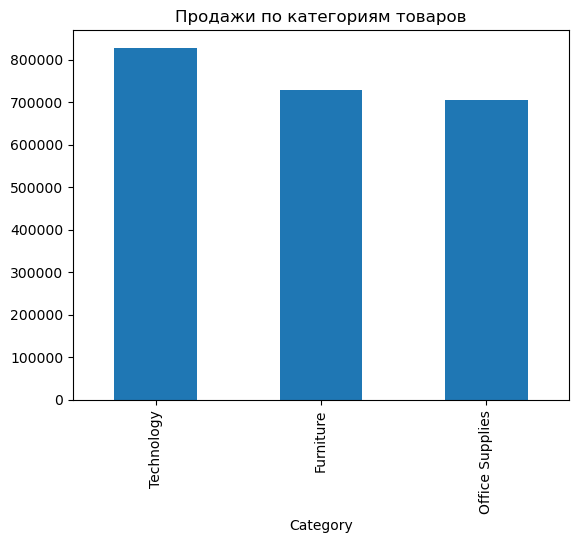

In [140]:
#и визуализируем
sales_by_category.plot(kind='bar')
plt.title('Продажи по категориям товаров')
plt.show()

---
Из графика видим, что по всем категориям продается *+- одинаковое количество* товара, хотя **техника** продает чуть лучше всего остального.

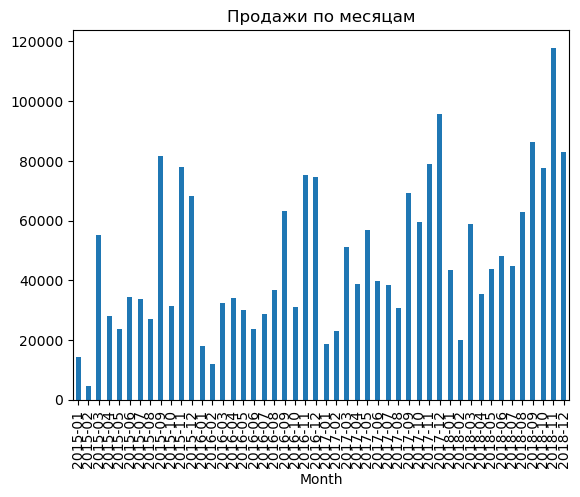

In [141]:
#Дальше смотрим и визуализируем продажи по месяцам

df['Month'] = df['Order Date'].dt.to_period('M')
sales_by_month = df.groupby('Month')['Sales'].sum()

sales_by_month.plot(kind='bar')
plt.title('Продажи по месяцам')
plt.show()

На графике видна ярко выраженная сезонность - в период за 3 года (2015-2017) самые высокие показатели продаж фиксируются в **сентябре, ноябре и декабре** с падением продаж **в октябре**.

Чтобы получше проанализировать выявленную закономерность, рассмотрим месячные продажи товаров непосресдственно по категориям.

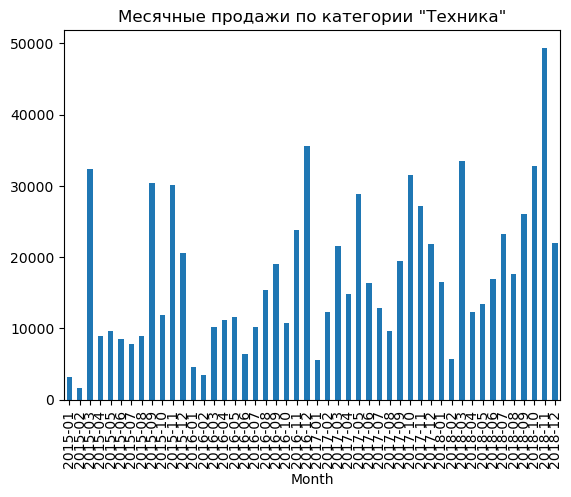

In [142]:
#Продажи техники

sales_by_month_category = df.query('Category == "Technology"').groupby('Month')['Sales'].sum()

sales_by_month_category.plot(kind='bar')
plt.title('Месячные продажи по категории "Техника"')
plt.show()

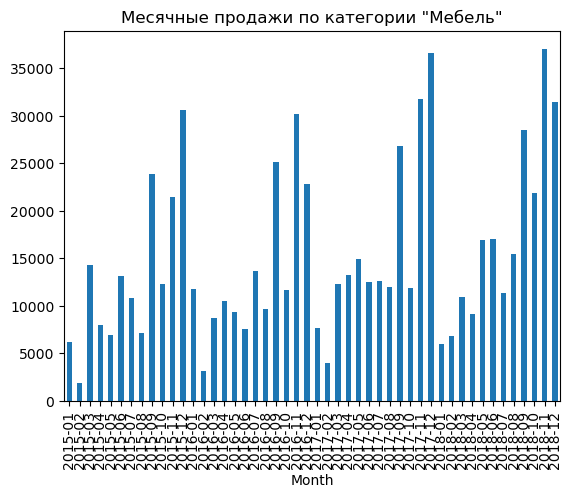

In [61]:
#Продажи мебели

sales_by_month_category = df.query('Category == "Furniture"').groupby('Month')['Sales'].sum()

sales_by_month_category.plot(kind='bar')
plt.title('Месячные продажи по категории "Мебель"')
plt.show()

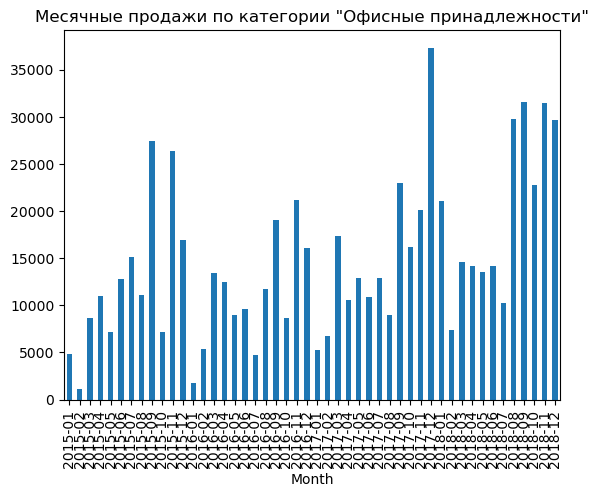

In [143]:
#Продажи офисных принадлежностей

sales_by_month_category = df.query('Category == "Office Supplies"').groupby('Month')['Sales'].sum()

sales_by_month_category.plot(kind='bar')
plt.title('Месячные продажи по категории "Офисные принадлежности"')
plt.show()

Видим, что выявленная ранее сезонность **подтверждается** на данных из категорий **"Мебель"** и **"Офисные принадлежности"** - пиковые продажи приходятся на *сентябрь*, *ноябрь* и *декабрь*. Что касается **техники**, то здесь сезонность выражается в росте продаж **в 4 квартале каждого года**, однако *внутри квартала* явной закономерности **нет**.

Далее найдем ТОП-20 *самых продаваемых товаров* в целом:

In [144]:
#добавляем аггрегирующие столбцы по сумме продаж и количеству проданного товара

top_products = (df.groupby(['Product Name', 'Category'])
                .agg(Сумма_продаж=('Sales', 'sum'), Количество=('Order ID', 'count'))
                .sort_values(by='Сумма_продаж', ascending=False)
                .head(20)
                .reset_index()
               )
#делаем красиво, чтобы индекс шел не с 0, а с 1
top_products.index = range(1, len(top_products) + 1)

print(top_products.to_string(max_colwidth=80))

                                                                   Product Name         Category  Сумма_продаж  Количество
1                                         Canon imageCLASS 2200 Advanced Copier       Technology    61599.8240           5
2   Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind  Office Supplies    27453.3840          10
3                         Cisco TelePresence System EX90 Videoconferencing Unit       Technology    22638.4800           1
4                                  HON 5400 Series Task Chairs for Big and Tall        Furniture    21870.5760           8
5                                    GBC DocuBind TL300 Electric Binding System  Office Supplies    19823.4790          11
6                              GBC Ibimaster 500 Manual ProClick Binding System  Office Supplies    19024.5000           9
7                                          Hewlett Packard LaserJet 3310 Copier       Technology    18839.6860           8
8               

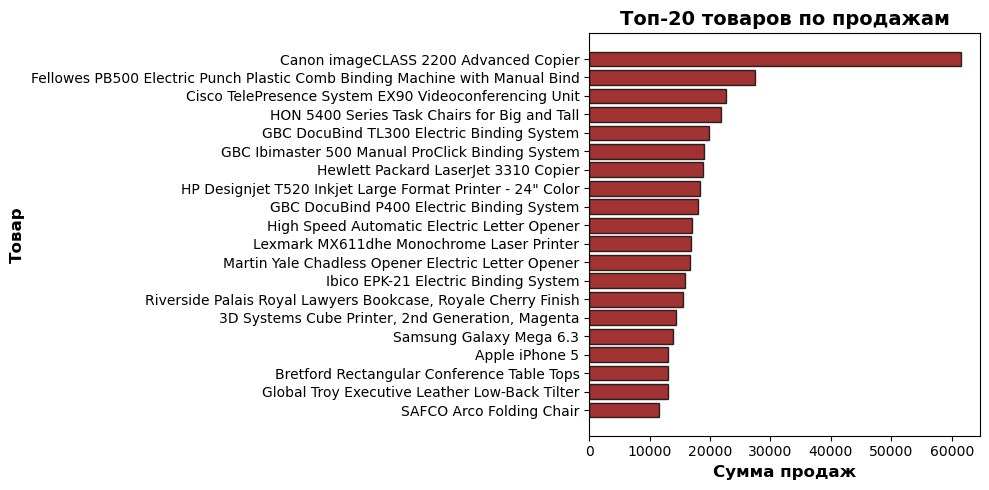

In [154]:
#визуализируем наш ТОП-20

plt.figure(figsize=(10, 5))
plt.barh(top_products['Product Name'], top_products['Сумма_продаж'], color='darkred', edgecolor='black', alpha=0.8, linewidth=1)
plt.xlabel('Сумма продаж', fontsize=12, fontweight='bold')
plt.ylabel('Товар', fontsize=12, fontweight='bold')
plt.title('Топ-20 товаров по продажам', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Таблица и график показывают, что самым продаваемым (с точки зрения выручки) является **копир Canon**. И в целом товары из категории *"Техника"* при достаточно небольших объемах продаж(количество) дают *очень хорошую выручку*.

_**ВАЖНО**_: с точки зрения анализа в датасете не хватает важнейшего показателя - **себестоимости продаваемых товаров**, из-за чего невозможно рассчитать *прибыль, рентабельность и оценить маржинальность товаров* в каждой категории. Техника, несмотря на свою высокую стоимость и небольшие объемы продаж может быть как высокомаржинальной, так и наоборот. Также невозможно и сделать вывод относительно дальнейшей стратегии компании - на что сделать упор, какую номенклатуру сократить/убрать. 

In [155]:
#также можно посмотреть на основную статистику в разрезе кактегорий товаров.

df['Year'] = df['Order Date'].dt.to_period('Y')

df.query('Category == "Technology"').groupby('Year')['Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2015,347.0,501.053334,1433.073424,1.980,70.959,199.980,500.980,22638.48
2016,405.0,400.636373,598.992851,2.376,71.976,199.960,494.376,4899.93
2017,450.0,493.248764,1261.058233,1.980,67.372,166.440,431.937,17499.95
2018,611.0,440.868561,1061.862361,0.990,65.990,151.188,424.772,13999.96


In [157]:
df.query('Category == "Furniture"').groupby('Year')['Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2015,414.0,377.965896,528.355540,3.480,51.962,182.86200,520.44000,4007.840
2016,440.0,372.849699,569.104673,2.960,53.349,191.66775,414.15525,4404.900
2017,547.0,357.976307,481.668631,2.328,47.676,187.05600,453.05850,3504.900
2018,677.0,313.609730,449.708876,1.892,41.960,171.28800,384.76800,4416.174


In [158]:
df.query('Category == "Office Supplies"').groupby('Year')['Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2015,1192.0,125.430218,465.269898,0.852,11.808,25.542,78.3155,9449.95
2016,1210.0,110.020171,316.384667,0.984,11.354,27.216,80.9550,6354.95
2017,1537.0,118.684168,400.446857,0.836,11.976,29.718,77.5200,9892.74
2018,1970.0,122.013980,352.579864,0.444,11.784,27.159,82.2900,5443.96


Видно, что правосторонюю ассиметрию в распределении значений во многом дает техника - здесь наблюдаются аномально высокие **MAX-значения** (*22638*) 

---
Еще можно посмотреть на динамику выручки в годовом разрезе:

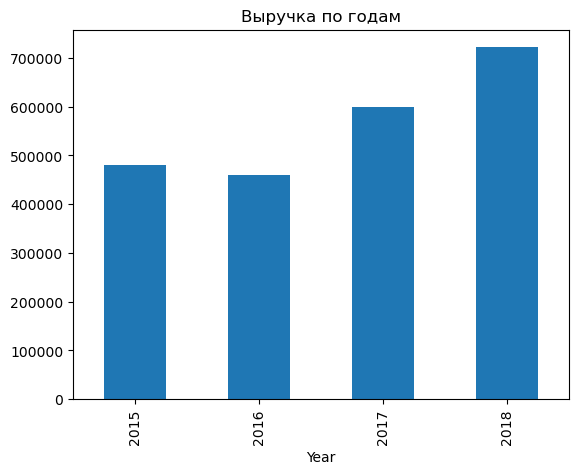

In [202]:
revenue_by_year = df.groupby('Year')['Sales'].sum()

revenue_by_year.plot(kind='bar')
plt.title('Выручка по годам')
plt.show()

**Также можно проанализировать динамиику продаж по штатам за 4 года.**

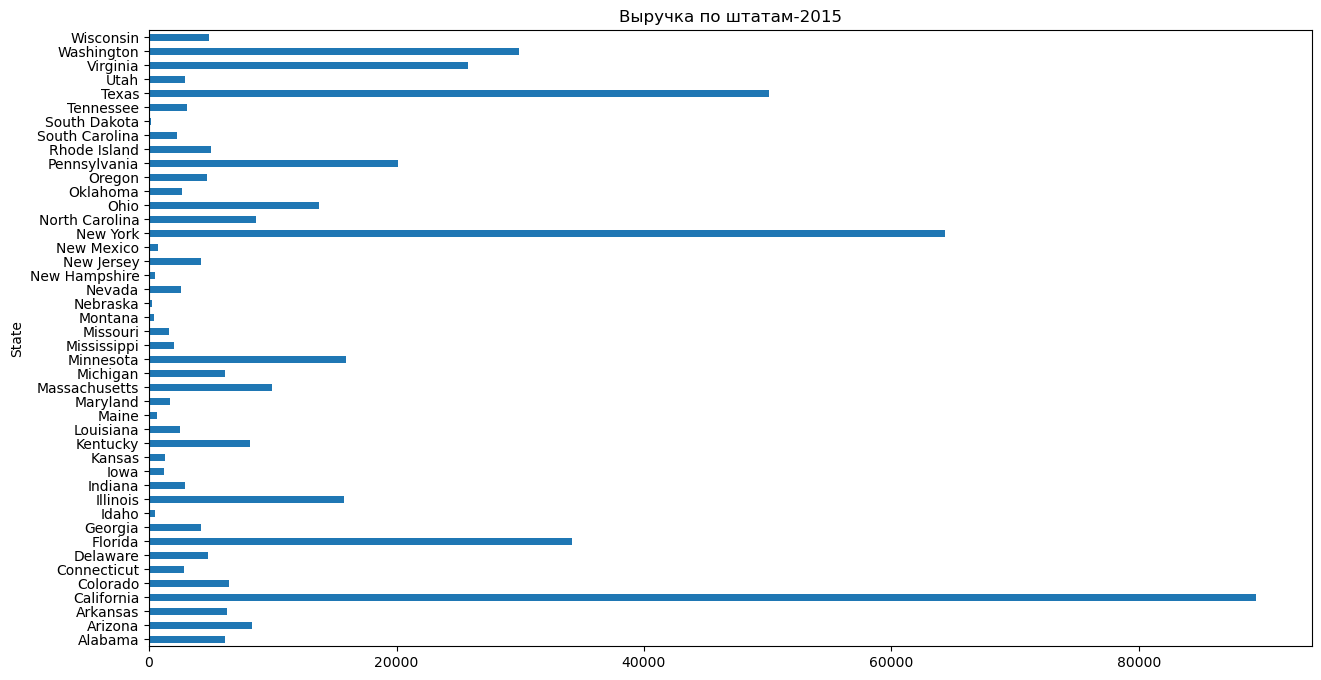

In [197]:
revenue_by_state_2015 = df.query('Year.dt.year == 2015').groupby('State')['Sales'].sum()

revenue_by_state_2015.plot(kind='barh', figsize=(15, 8))
plt.title('Выручка по штатам-2015')
plt.show()

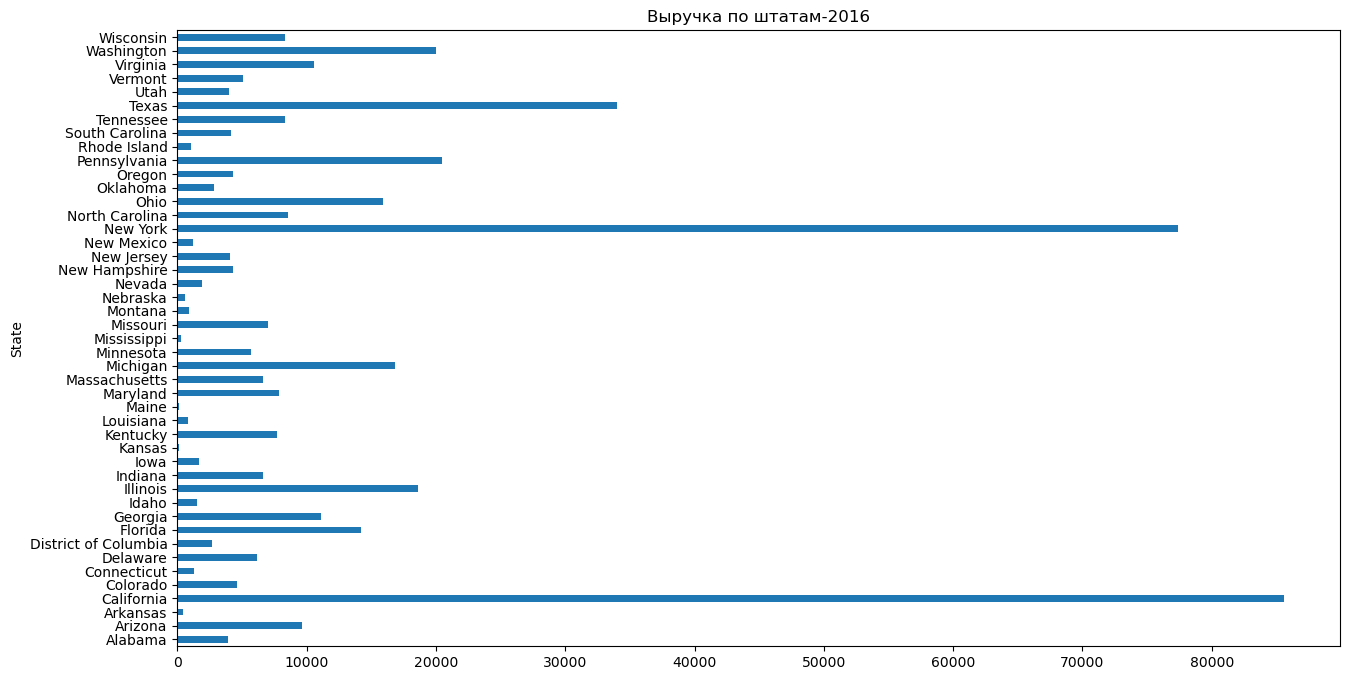

In [198]:
revenue_by_state_2016 = df.query('Year.dt.year == 2016').groupby('State')['Sales'].sum()

revenue_by_state_2016.plot(kind='barh', figsize=(15, 8))
plt.title('Выручка по штатам-2016')
plt.show()

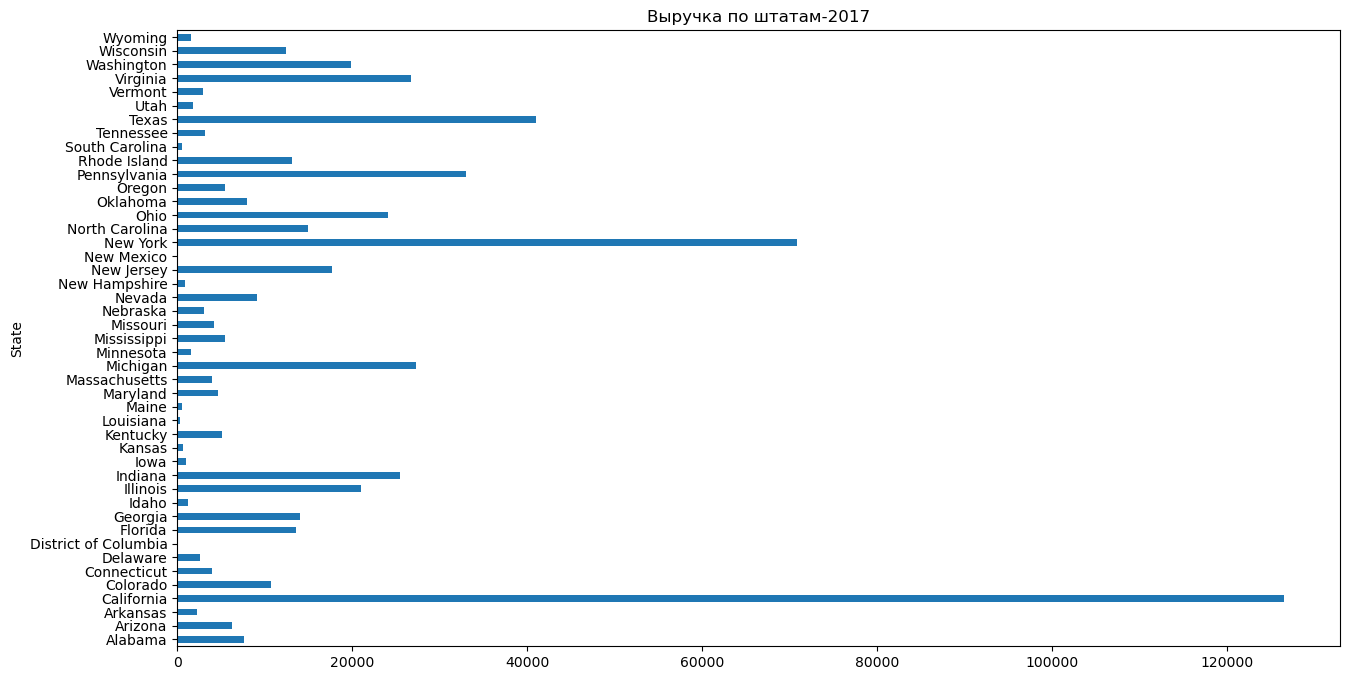

In [199]:
revenue_by_state_2017 = df.query('Year.dt.year == 2017').groupby('State')['Sales'].sum()

revenue_by_state_2017.plot(kind='barh', figsize=(15, 8))
plt.title('Выручка по штатам-2017')
plt.show()

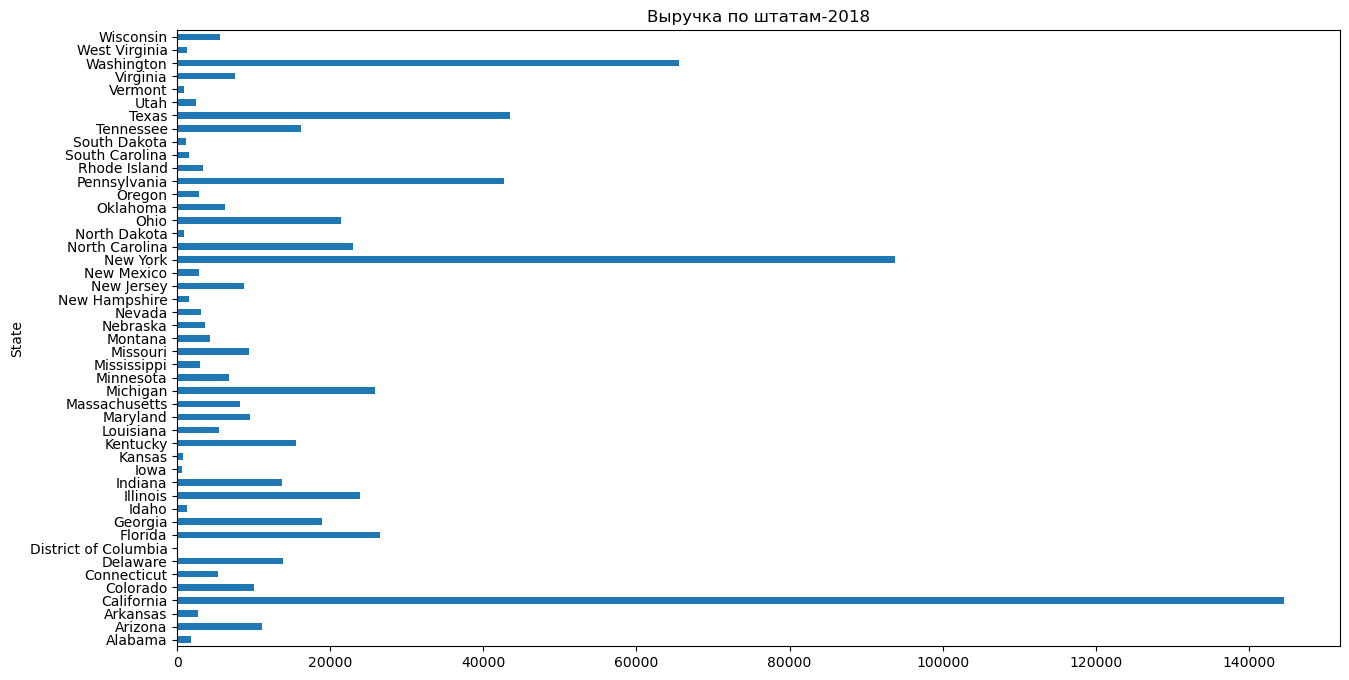

In [200]:
revenue_by_state_2018 = df.query('Year.dt.year == 2018').groupby('State')['Sales'].sum()

revenue_by_state_2018.plot(kind='barh', figsize=(15, 8))
plt.title('Выручка по штатам-2018')
plt.show()

В целом, графики показывают, что есть 2 штата с максимальными (и стабильными) продажами - _**Нью-йорк и Калифорния**_. Кроме них ,есть несколько штатов, которые в разные годы входили в _ТОП-5_: **Мичиган, Пенсильвания, Техас, Вашингтон, Вирджиниа, Иллинойс, Флорида**. Полезно было бы изучить, какие факторы влияли на волатильность продаж в этих штатах, чтобы скорректировать стратегию продаж.

---
**ВЫВОДЫ**:
1. Товары из категории **"Техника"** генерируют больше выручки, чем две другие категории. В условиях отсутствия данных о себестоимости можно _посоветовать_ **масштабировать ассортимент в этой категории и усилить маркетинг** - в особенности, ближе к 4 кварталу года.
2. Нужно проанализировать продажи в штатах **Мичиган, Пенсильвания, Техас, Вашингтон, Вирджиниа, Иллинойс, Флорида**. Есть потенциал роста продаж в этих штатах при реализации правильной стратегии.
